## 1. Problem Understanding

1. **Prediction Target:** The target variable is `Appliances`, which represents household appliance energy consumption measured in Wh (watt-hours).

2. **Objective:** The objective is to predict the energy consumption of household appliances using environmental and sensor measurements.

3. **Problem Type:** This is a Supervised Machine Learning – Regression problem because the target variable is a continuous numerical value.

4. **Input Features:** The dataset contains indoor temperature, humidity, lighting, and outdoor weather-related measurements that can be used as input features.

5. **Real-World Use:** The model can help understand household energy consumption patterns and support smart-home energy management.

6. **Intended Output:** The model will produce a numerical prediction representing the expected appliance energy consumption in Wh.

7. **Model Comparison:** Four regression models—Linear Regression, Random Forest Regressor, Gradient Boosting Regressor, and Artificial Neural Network (ANN)—will be trained and compared using MAE, RMSE, and R².

In [22]:
# Import required libraries

# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing and splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Artificial Neural Network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("Libraries imported successfully!")

Libraries imported successfully!


In [23]:
# Load the dataset
df = pd.read_csv('/content/appliances+energy+prediction.zip')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [24]:
# Display the first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [25]:
# Check the number of rows and columns
print("\nShape of the dataset:")
print(df.shape)



Shape of the dataset:
(19735, 29)


In [26]:
# Check column names, data types, and non-null values
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-n

In [27]:
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


In [28]:
# Target variable distribution
print("\nTarget Variable (Appliances) Distribution:")
display(df['Appliances'].describe())


Target Variable (Appliances) Distribution:


,Appliances
count,19735.000000
mean,97.694958
std,102.524891
min,10.000000
25%,50.000000
50%,60.000000
75%,100.000000
max,1080.000000


In [29]:
# Check missing values in each column

df.isnull().sum()

,0
date,0
Appliances,0
lights,0
T1,0
RH_1,0
T2,0
RH_2,0
T3,0
RH_3,0
T4,0


In [30]:
# Check for duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [31]:
# Check data types of all columns

df.dtypes

,0
date,object
Appliances,int64
lights,int64
T1,float64
RH_1,float64
T2,float64
RH_2,float64
T3,float64
RH_3,float64
T4,float64


In [32]:
# Check minimum value of each numerical column

df.select_dtypes(include=['int64', 'float64']).min()

,0
Appliances,10.000000
lights,0.000000
T1,16.790000
RH_1,27.023333
T2,16.100000
RH_2,20.463333
T3,17.200000
RH_3,28.766667
T4,15.100000
RH_4,27.660000


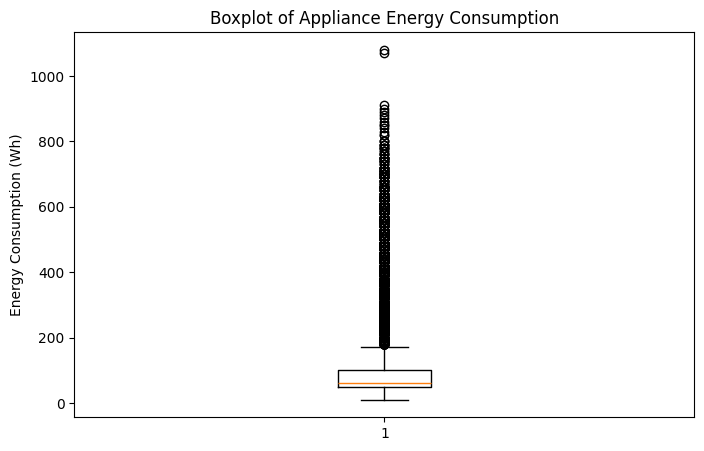

In [33]:


plt.figure(figsize=(8, 5))

plt.boxplot(df['Appliances'])

plt.title('Boxplot of Appliance Energy Consumption')
plt.ylabel('Energy Consumption (Wh)')

plt.show()

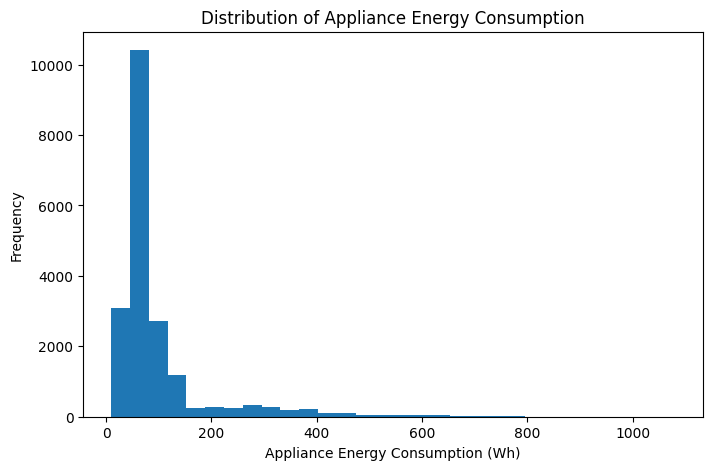

In [34]:
#EDA_PERFORM
plt.figure(figsize=(8, 5))

plt.hist(df['Appliances'], bins=30)

plt.title('Distribution of Appliance Energy Consumption')
plt.xlabel('Appliance Energy Consumption (Wh)')
plt.ylabel('Frequency')

plt.show()

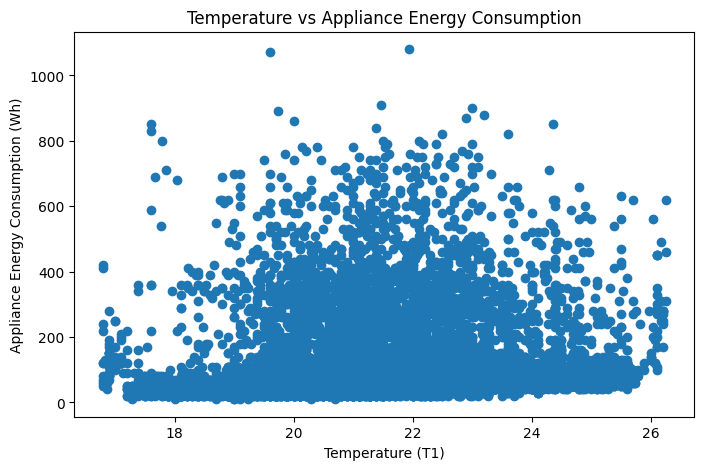

In [35]:
plt.figure(figsize=(8, 5))

plt.scatter(df['T1'], df['Appliances'])

plt.title('Temperature vs Appliance Energy Consumption')
plt.xlabel('Temperature (T1)')
plt.ylabel('Appliance Energy Consumption (Wh)')

plt.show()

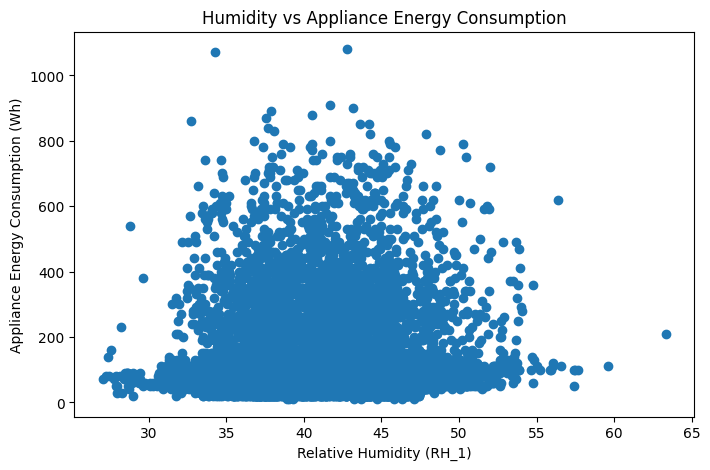

In [36]:
plt.figure(figsize=(8, 5))

plt.scatter(df['RH_1'], df['Appliances'])

plt.title('Humidity vs Appliance Energy Consumption')
plt.xlabel('Relative Humidity (RH_1)')
plt.ylabel('Appliance Energy Consumption (Wh)')

plt.show()

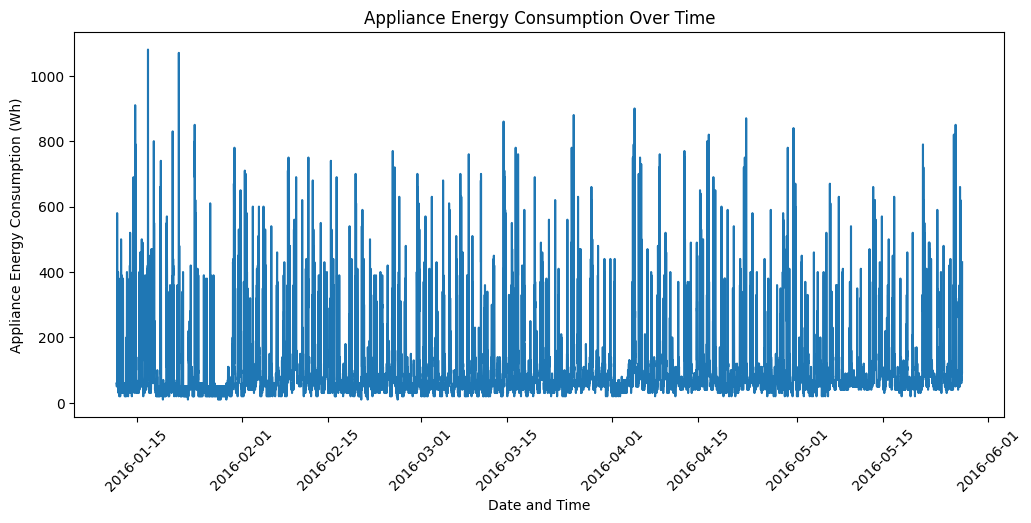

In [37]:
df['date'] = pd.to_datetime(df['date'])
plt.figure(figsize=(12, 5))

plt.plot(df['date'], df['Appliances'])

plt.title('Appliance Energy Consumption Over Time')
plt.xlabel('Date and Time')
plt.ylabel('Appliance Energy Consumption (Wh)')

plt.xticks(rotation=45)
plt.show()

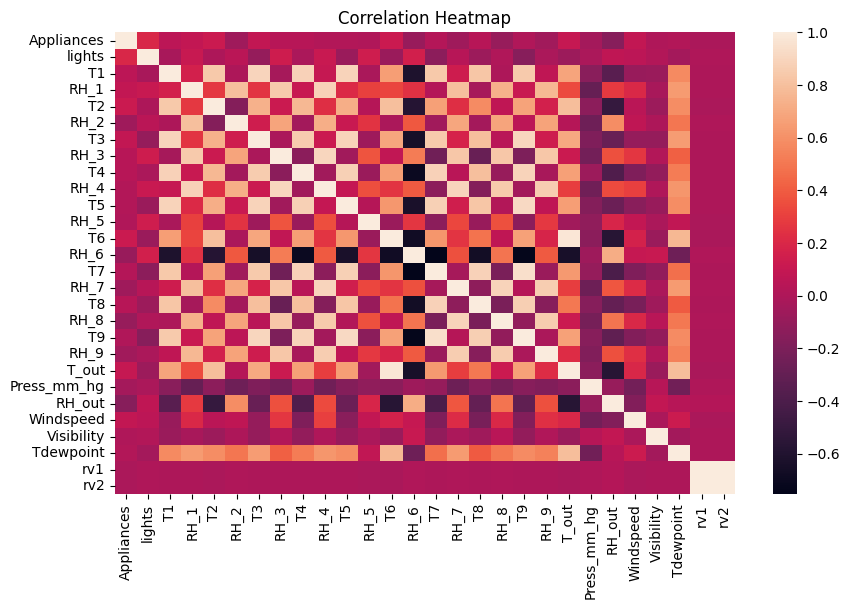

In [38]:
plt.figure(figsize=(10, 6))

corr = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(corr)

plt.title('Correlation Heatmap')

plt.show()

EDA Insights:

1. Appliance energy consumption is highly right-skewed, with most observations showing low consumption and a smaller number of very high consumption values.

2. Temperature (T1) does not show a strong direct relationship with appliance energy consumption, as the scatter plot contains widely distributed points.

3. Relative humidity (RH_1) also shows  clear direct relationship with appliance energy consumption.

4. Appliance energy consumption varies considerably over time, with a low baseline and frequent sudden spikes.

5. The correlation heatmap shows noticeable correlations among several temperature and humidity sensor variables, while the relationship between individual environmental variables and appliance consumption is comparatively weaker.

In [39]:
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.weekday

In [40]:
df[['date', 'hour', 'day', 'month', 'weekday']].head()

,date,hour,day,month,weekday
0,2016-01-11 17:00:00,17,11,1,0
1,2016-01-11 17:10:00,17,11,1,0
2,2016-01-11 17:20:00,17,11,1,0
3,2016-01-11 17:30:00,17,11,1,0
4,2016-01-11 17:40:00,17,11,1,0


In [41]:
df = df.drop('date', axis=1)

In [42]:
df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,hour,day,month,weekday
0,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,92.0,7.000000,63.000000,5.3,13.275433,13.275433,17,11,1,0
1,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,92.0,6.666667,59.166667,5.2,18.606195,18.606195,17,11,1,0
2,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,92.0,6.333333,55.333333,5.1,28.642668,28.642668,17,11,1,0
3,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,92.0,6.000000,51.500000,5.0,45.410389,45.410389,17,11,1,0
4,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,92.0,5.666667,47.666667,4.9,10.084097,10.084097,17,11,1,0


In [43]:
df.shape

(19735, 32)

In [44]:
#separate feature and target
X = df.drop('Appliances', axis=1)
y = df['Appliances']

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

In [46]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (15788, 31)
X_test: (3947, 31)
y_train: (15788,)
y_test: (3947,)


In [48]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [50]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [51]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

Linear Regression Results
MAE: 52.56973424453629
RMSE: 91.1237670924913
R²: 0.1702343017489495


In [52]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [53]:
y_pred_rf = rf_model.predict(X_test)

In [54]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Results
MAE: 32.04915125411705
RMSE: 67.37072594957989
R²: 0.5464401520571318


In [55]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [56]:
y_pred_gb = gb_model.predict(X_test)

In [57]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R²:", r2_gb)

Gradient Boosting Results
MAE: 45.47862741371301
RMSE: 83.19629107531885
R²: 0.30832818612033897


In [58]:
from sklearn.neural_network import MLPRegressor

ann_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=42
)

ann_model.fit(X_train_scaled, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

In [59]:
y_pred_ann = ann_model.predict(X_test_scaled)

In [60]:
mae_ann = mean_absolute_error(y_test, y_pred_ann)
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))
r2_ann = r2_score(y_test, y_pred_ann)

print("ANN Results")
print("MAE:", mae_ann)
print("RMSE:", rmse_ann)
print("R²:", r2_ann)

ANN Results
MAE: 45.36617432003499
RMSE: 77.7093425978299
R²: 0.3965537167369355


In [61]:
results = {
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'ANN'
    ],
    'MAE': [
        mae_lr,
        mae_rf,
        mae_gb,
        mae_ann
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf,
        rmse_gb,
        rmse_ann
    ],
    'R2': [
        r2_lr,
        r2_rf,
        r2_gb,
        r2_ann
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,52.569734,91.123767,0.170234
1,Random Forest,32.049151,67.370726,0.546440
2,Gradient Boosting,45.478627,83.196291,0.308328
3,ANN,45.366174,77.709343,0.396554


Model Selection:

Random Forest was selected as the best-performing model among the four tested models. It achieved the lowest MAE of 32 and the lowest RMSE of 67, indicating that its predictions had smaller errors compared with the other models. It also achieved the highest R² score of 0.54, meaning that it explained a larger portion of the variation in appliance energy consumption.

Therefore, Random Forest provided the best overall balance across all three evaluation metrics, rather than being selected based on a single metric. Since all models were evaluated on the same test set, this comparison is fair.

In [62]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
27,hour,0.151277
5,T3,0.058331
6,RH_3,0.043381
10,RH_5,0.039309
20,Press_mm_hg,0.037257
15,T8,0.036424
4,RH_2,0.034818
2,RH_1,0.031726
24,Tdewpoint,0.031559
3,T2,0.029406


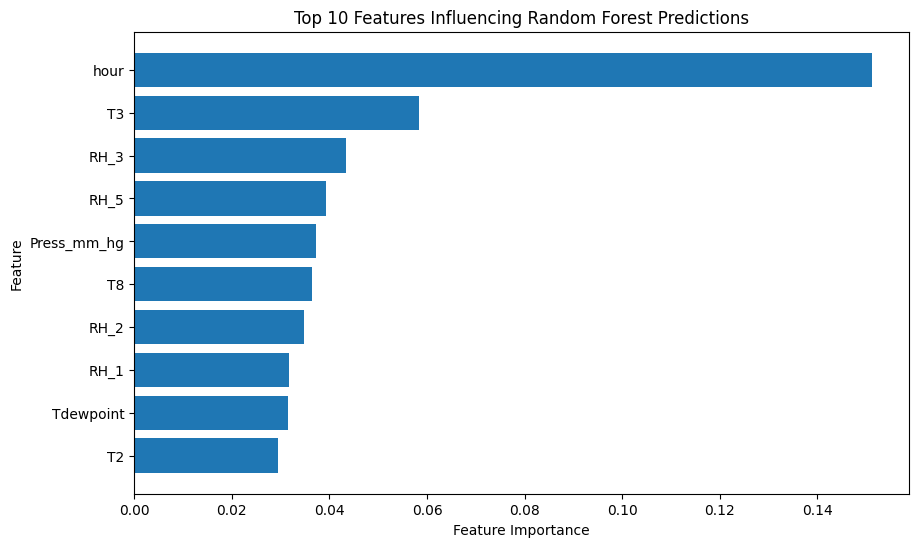

In [63]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Features Influencing Random Forest Predictions')
plt.gca().invert_yaxis()
plt.show()

In [72]:
sample = X_test.iloc[[10]]
prediction = rf_model.predict(sample)

print("Predicted Appliances:", prediction[0])

Predicted Appliances: 235.1


In [ ]:
sample = X_test.iloc[[10]]

actual_value = y_test.iloc[10]

predicted_value = rf_model.predict(sample)[0]

print("Smart Home Energy Consumption Prediction")
print("------------------------------------------")
print("Actual Appliances Consumption:", actual_value)
print("Predicted Appliances Consumption:", predicted_value)

Smart Home Energy Consumption Prediction
------------------------------------------
Actual Appliances Consumption: 40
Predicted Appliances Consumption: 52.6


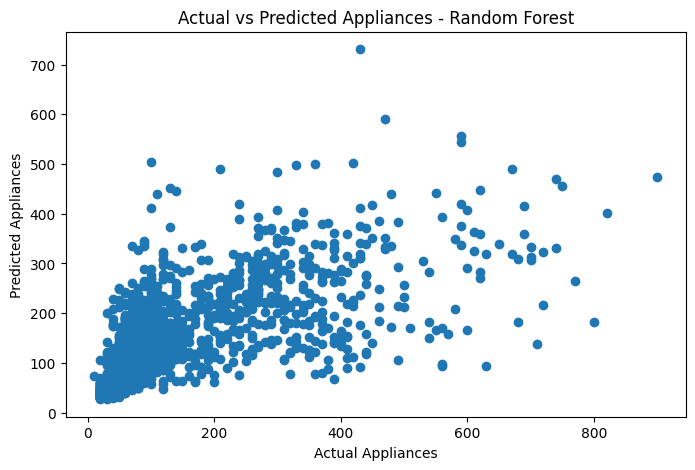

In [74]:
#Actual vs Predicted
y_pred_rf = rf_model.predict(X_test)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Appliances")
plt.ylabel("Predicted Appliances")
plt.title("Actual vs Predicted Appliances - Random Forest")
plt.show()

In [75]:
#OVERFITTING CHECK

In [76]:
# Predictions on training data
y_train_pred = rf_model.predict(X_train)

# Predictions on test data
y_test_pred = rf_model.predict(X_test)

# Training metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# Testing metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("Random Forest - Training Performance")
print("MAE:", train_mae)
print("RMSE:", train_rmse)
print("R²:", train_r2)

print("\nRandom Forest - Testing Performance")
print("MAE:", test_mae)
print("RMSE:", test_rmse)
print("R²:", test_r2)

Random Forest - Training Performance
MAE: 12.423473524195591
RMSE: 26.44863577637254
R²: 0.9342325914221082

Random Forest - Testing Performance
MAE: 32.04915125411705
RMSE: 67.37072594957989
R²: 0.5464401520571318


In [77]:
# Random Forest predictions
y_pred_rf = rf_model.predict(X_test)

# Calculate errors
errors = y_test - y_pred_rf

print("Mean Error:", errors.mean())
print("Minimum Error:", errors.min())
print("Maximum Error:", errors.max())

Mean Error: -2.3451228781352924
Minimum Error: -404.8
Maximum Error: 617.3


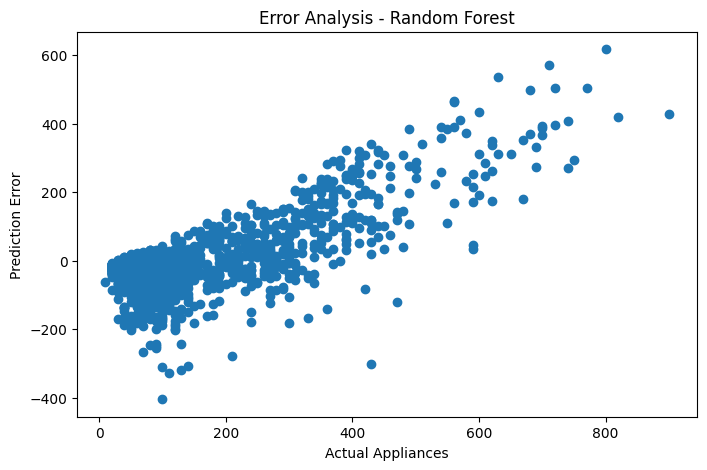

In [79]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, errors)

plt.xlabel("Actual Appliances")
plt.ylabel("Prediction Error")
plt.title("Error Analysis - Random Forest")

plt.show()

1. Which model has the lowest MAE / RMSE?


     Random Forest has the lowest MAE and RMSE.
     MAE: 32.05
     RMSE: 67.37

2. Which model has the strongest R²?
    
     Random Forest has the strongest R².
     R²: 0.546

3. Are errors concentrated in certain ranges?
    
     Yes. Errors are relatively smaller at low appliance consumption levels but become larger and more spread out as actual appliance consumption increases. The model struggles more with higher consumption values.

4. Does the model appear to overfit?
   
     Yes. Random Forest shows signs of overfitting because its training performance is much better than its testing performance.

     Training:
     MAE: 12.42
     RMSE: 26.45
     R²: 0.934

    Testing:
    MAE: 32.05
    RMSE: 67.37
    R²: 0.546